In [1]:
import os

import ast
import pandas as pd
import numpy as np
import seaborn as sns
from ydata_profiling import ProfileReport
import re

import matplotlib.pyplot as plt
%matplotlib inline

C:\Users\SIDov\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PATH_OUT = r'D:\code_files\Python\data_analysis_yandex\yandex_final\git\SADTeam\Настя'

In [2]:
df = pd.read_csv('rides.csv', sep=',', encoding='utf-8', skipinitialspace=True, decimal=',')
df

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0
...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,Озерная,Юго-Восточный,Первомайская,Северо-Западный,3302.0,0
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,Мичурина,Ленинский,Садовая,Заречный,4992.0,0
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,Лермонтова,ленинский,Куйбышева,Центральный,2781.0,0
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,Рябиновая,Северо-Западный,Энергетиков,Юго-Восточный,6466.0,0


In [3]:
df1 = df.copy()
df2 = df.copy()

In [4]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Id              102255 non-null  int64 
 1   Start Date      102255 non-null  object
 2   End Date        102255 non-null  object
 3   Start Location  102255 non-null  object
 4   Start District  102255 non-null  object
 5   End Location    102255 non-null  object
 6   End District    102255 non-null  object
 7   Distance        101022 non-null  object
 8   Promo           102255 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 7.0+ MB


In [5]:
df2.dropna(subset=['Start Date', 'End Date'], inplace=True)
df2["Distance"].isna().sum()
df2.dropna(subset=["Distance"], inplace=True)
df2['Start Date'] = pd.to_datetime(df2['Start Date'])
df2['End Date'] = pd.to_datetime(df2['End Date'])
df2.dropna(subset=['Start Date', 'End Date'], inplace=True)

df2[df2.isnull().any(axis=1)]
#print(df2.isnull().sum())
#df2[df2.isnull().any(axis=1)]
df2

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0
...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,Озерная,Юго-Восточный,Первомайская,Северо-Западный,3302.0,0
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,Мичурина,Ленинский,Садовая,Заречный,4992.0,0
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,Лермонтова,ленинский,Куйбышева,Центральный,2781.0,0
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,Рябиновая,Северо-Западный,Энергетиков,Юго-Восточный,6466.0,0


In [6]:
def normalize_street_name(name):
    if pd.isna(name):
        return name

    name = str(name).strip().lower()  # всё сразу в нижний регистр

    # Удаляем существующие префиксы
    if name.startswith(('ул.', 'ул ')):
        parts = name.split(maxsplit=1)
        name = parts[1] if len(parts) > 1 else ''

    name = name.replace('.', '').strip()

    if not name:
        return np.nan

    return f'ул. {name}'  # всё в нижнем регистре

# Применяем к улицам
df2['Start Location'] = df2['Start Location'].apply(normalize_street_name)
df2['End Location'] = df2['End Location'].apply(normalize_street_name)

# Районы тоже в нижний регистр
df2['Start District'] = df2['Start District'].apply(lambda x: x.lower() if isinstance(x, str) else x)
df2['End District'] = df2['End District'].apply(lambda x: x.lower() if isinstance(x, str) else x)

df2['Start District'] = df2['Start District'].str.replace('северо западный', 'северо-западный')
df2['End District'] = df2['End District'].str.replace('северо западный', 'северо-западный')

df2['Start District'].unique()

array(['юго-восточный', 'заречный', 'октябрьский', 'центральный',
       'северо-западный', 'ленинский'], dtype=object)

In [7]:
def normalize_street_name(name):
    if pd.isna(name):
        return name

    name = str(name).strip().lower()  #всё сразу в нижний регистр

    # Удаляем существующие префиксы
    if name.startswith(('ул.', 'ул ')):
        parts = name.split(maxsplit=1)
        name = parts[1] if len(parts) > 1 else ''

    name = name.replace('.', '').strip()

    if not name:
        return np.nan

    return f'ул. {name}'  

df['Start Location'] = df['Start Location'].apply(normalize_street_name)
df['End Location'] = df['End Location'].apply(normalize_street_name)

df['Start District'] = df['Start District'].apply(lambda x: x.lower() if isinstance(x, str) else x)
df['End District'] = df['End District'].apply(lambda x: x.lower() if isinstance(x, str) else x)

df['Start District'] = df['Start District'].str.replace('северо западный', 'северо-западный')
df['End District'] = df['End District'].str.replace('северо западный', 'северо-западный')

In [8]:
df2['Start Month'] = df2['Start Date'].dt.month
df2['End Month'] = df2['End Date'].dt.month
seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}
df2['Start Season'] = df2['Start Month'].map(seasons)
df2['End Season'] = df2['End Month'].map(seasons)

df2['Time start'] = df2['Start Date'].dt.time
df2['Time end'] = df2['End Date'].dt.time
df2['Trip Duration'] = (df2['End Date'] - df2['Start Date']).dt.total_seconds() / 60

df2['Distance'] = pd.to_numeric(df2['Distance'], errors='coerce')
df2['Speed (km/h)'] = (df2['Distance'] / 1000) / (df2['Trip Duration'] / 60)

df2 = df2.copy()

#gap = df2['Distance'][df2['Distance'] > 3000000].count()

df2 = df2[df2['Distance'] < 1000000]
df2 = df2[df2['Speed (km/h)'] <= 50]
df2 = df2[df2['Distance'] <= 10000]

season_mapping = {"Весна": 1, "Лето": 2, "Осень": 3, "Зима": 4}
df22= df2.copy()
df22["Season_Num"] = df22["Start Season"].map(season_mapping)

correlation = df22["Trip Duration"].corr(df22["Season_Num"]) #пирсон
correlation1 = df22["Distance"].corr(df22["Season_Num"])

print(f"Корреляция между длительностью поездки и временем года: {correlation:.4f}")
print(f"Корреляция между длиной поездки и временем года: {correlation1:.4f}")

df2

Корреляция между длительностью поездки и временем года: -0.0010
Корреляция между длиной поездки и временем года: -0.0009


,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,End Month,Start Season,End Season,Time start,Time end,Trip Duration,Speed (km/h)
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,ул. шевченко,юго-восточный,ул. майская,октябрьский,4069.0,0,4,4,Весна,Весна,09:01:03,09:24:45,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,ул. чехова,заречный,ул. спортивная,октябрьский,4515.0,0,4,4,Весна,Весна,09:01:07,09:29:32,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,ул. буденного,октябрьский,ул. суворова,ленинский,4520.0,0,4,4,Весна,Весна,09:04:27,09:42:46,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,ул. труда,центральный,ул. рабочая,северо-западный,3881.0,0,4,4,Весна,Весна,09:06:34,09:38:23,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,ул. первомайская,северо-западный,ул. юбилейная,юго-восточный,4029.0,0,4,4,Весна,Весна,09:09:27,09:40:07,30.666667,7.882826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,ул. озерная,юго-восточный,ул. первомайская,северо-западный,3302.0,0,7,8,Лето,Лето,23:45:06,00:06:55,21.816667,9.081131
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,ул. мичурина,ленинский,ул. садовая,заречный,4992.0,0,7,8,Лето,Лето,23:46:01,00:25:35,39.566667,7.570008
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,ул. лермонтова,ленинский,ул. куйбышева,центральный,2781.0,0,7,8,Лето,Лето,23:48:04,00:09:21,21.283333,7.839937
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,ул. рябиновая,северо-западный,ул. энергетиков,юго-восточный,6466.0,0,7,8,Лето,Лето,23:51:41,00:38:04,46.383333,8.364211


In [9]:
def time_day(x):
    if 5 <= x <= 12:
        return 'Утро'
    elif 12 < x <= 18:
        return 'День'
    elif 18 < x <= 22:
        return 'Вечер'
    return 'Ночь'

df2['Time of Day'] = df2['Start Date'].apply(lambda x: time_day(x.hour))
df2

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,End Month,Start Season,End Season,Time start,Time end,Trip Duration,Speed (km/h),Time of Day
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,ул. шевченко,юго-восточный,ул. майская,октябрьский,4069.0,0,4,4,Весна,Весна,09:01:03,09:24:45,23.700000,10.301266,Утро
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,ул. чехова,заречный,ул. спортивная,октябрьский,4515.0,0,4,4,Весна,Весна,09:01:07,09:29:32,28.416667,9.533138,Утро
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,ул. буденного,октябрьский,ул. суворова,ленинский,4520.0,0,4,4,Весна,Весна,09:04:27,09:42:46,38.316667,7.077860,Утро
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,ул. труда,центральный,ул. рабочая,северо-западный,3881.0,0,4,4,Весна,Весна,09:06:34,09:38:23,31.816667,7.318806,Утро
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,ул. первомайская,северо-западный,ул. юбилейная,юго-восточный,4029.0,0,4,4,Весна,Весна,09:09:27,09:40:07,30.666667,7.882826,Утро
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,ул. озерная,юго-восточный,ул. первомайская,северо-западный,3302.0,0,7,8,Лето,Лето,23:45:06,00:06:55,21.816667,9.081131,Ночь
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,ул. мичурина,ленинский,ул. садовая,заречный,4992.0,0,7,8,Лето,Лето,23:46:01,00:25:35,39.566667,7.570008,Ночь
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,ул. лермонтова,ленинский,ул. куйбышева,центральный,2781.0,0,7,8,Лето,Лето,23:48:04,00:09:21,21.283333,7.839937,Ночь
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,ул. рябиновая,северо-западный,ул. энергетиков,юго-восточный,6466.0,0,7,8,Лето,Лето,23:51:41,00:38:04,46.383333,8.364211,Ночь


In [10]:
all_districts = pd.concat([
    df2['Start District'], 
    df2['End District']
]).unique()
# Создаем DataFrame с уникальными районами
districts_df = pd.DataFrame({'District': all_districts})

# Добавляем статистику по каждому району
districts_df['Start Count'] = districts_df['District'].apply(
    lambda x: df2[df2['Start District'] == x].shape[0])
districts_df['End Count'] = districts_df['District'].apply(
    lambda x: df2[df2['End District'] == x].shape[0])
districts_df['Total Trips'] = districts_df['Start Count'] + districts_df['End Count']

# Сортируем по количеству поездок
districts_df = districts_df.sort_values('Total Trips', ascending=False).reset_index(drop=True)

print(districts_df)

correlations_by_start_district = df2.groupby('Start District').apply(
    lambda x: x['Trip Duration'].corr(x['Distance'])
)
print(correlations_by_start_district)


          District  Start Count  End Count  Total Trips
0      центральный        25740      25068        50808
1    юго-восточный        18946      19354        38300
2  северо-западный        15894      16146        32040
3        ленинский        15936      16016        31952
4      октябрьский        13724      13958        27682
5         заречный         9583       9281        18864
Start District
заречный           0.567805
ленинский          0.587329
октябрьский        0.522128
северо-западный    0.597246
центральный        0.541846
юго-восточный      0.608538
dtype: float64


C:\Users\SIDov\AppData\Local\Temp\ipykernel_18728\3493248591.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlations_by_start_district = df2.groupby('Start District').apply(


In [11]:
def get_rate(weekday, hour):
    if weekday < 5:  # Пн–Пт
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 5
        elif 16 <= hour < 22:
            return 6
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 5
    else:  # Сб–Вс
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 6
        elif 16 <= hour < 22:
            return 7
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 6


df2['Weekday'] = df2['Start Date'].dt.weekday
df2['Start Hour'] = df2['Start Date'].dt.hour

df2['Rate per Minute'] = df2.apply(lambda row: get_rate(row['Weekday'], row['Start Hour']), axis=1)

df2['Trip Cost'] = df2['Trip Duration'] * df2['Rate per Minute']
df2

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,...,End Season,Time start,Time end,Trip Duration,Speed (km/h),Time of Day,Weekday,Start Hour,Rate per Minute,Trip Cost
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,ул. шевченко,юго-восточный,ул. майская,октябрьский,4069.0,0,4,...,Весна,09:01:03,09:24:45,23.700000,10.301266,Утро,5,9,4,94.800000
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,ул. чехова,заречный,ул. спортивная,октябрьский,4515.0,0,4,...,Весна,09:01:07,09:29:32,28.416667,9.533138,Утро,5,9,4,113.666667
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,ул. буденного,октябрьский,ул. суворова,ленинский,4520.0,0,4,...,Весна,09:04:27,09:42:46,38.316667,7.077860,Утро,5,9,4,153.266667
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,ул. труда,центральный,ул. рабочая,северо-западный,3881.0,0,4,...,Весна,09:06:34,09:38:23,31.816667,7.318806,Утро,5,9,4,127.266667
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,ул. первомайская,северо-западный,ул. юбилейная,юго-восточный,4029.0,0,4,...,Весна,09:09:27,09:40:07,30.666667,7.882826,Утро,5,9,4,122.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,ул. озерная,юго-восточный,ул. первомайская,северо-западный,3302.0,0,7,...,Лето,23:45:06,00:06:55,21.816667,9.081131,Ночь,0,23,5,109.083333
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,ул. мичурина,ленинский,ул. садовая,заречный,4992.0,0,7,...,Лето,23:46:01,00:25:35,39.566667,7.570008,Ночь,0,23,5,197.833333
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,ул. лермонтова,ленинский,ул. куйбышева,центральный,2781.0,0,7,...,Лето,23:48:04,00:09:21,21.283333,7.839937,Ночь,0,23,5,106.416667
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,ул. рябиновая,северо-западный,ул. энергетиков,юго-восточный,6466.0,0,7,...,Лето,23:51:41,00:38:04,46.383333,8.364211,Ночь,0,23,5,231.916667


In [12]:
# Группируем по району и признаку промо
promo_stats = df2.groupby(['Start District', 'Promo']).size().unstack(fill_value=0)
promo_stats.columns = ['Без промо', 'С промо']
promo_stats['Всего поездок'] = promo_stats['Без промо'] + promo_stats['С промо']

# Доля промо-поездок
promo_stats['Доля промо'] = promo_stats['С промо'] / promo_stats['Всего поездок']
promo_stats = promo_stats.sort_values(by='Доля промо', ascending=False)

promo_stats

,Без промо,С промо,Всего поездок,Доля промо
Start District,,,,
заречный,9364,219,9583,0.022853
северо-западный,15541,353,15894,0.022210
ленинский,15589,347,15936,0.021775
юго-восточный,18547,399,18946,0.021060
октябрьский,13444,280,13724,0.020402
центральный,25366,374,25740,0.014530


C:\Users\SIDov\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\SIDov\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\SIDov\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\SIDov\AppData\Local\Programs\Python\Python310\

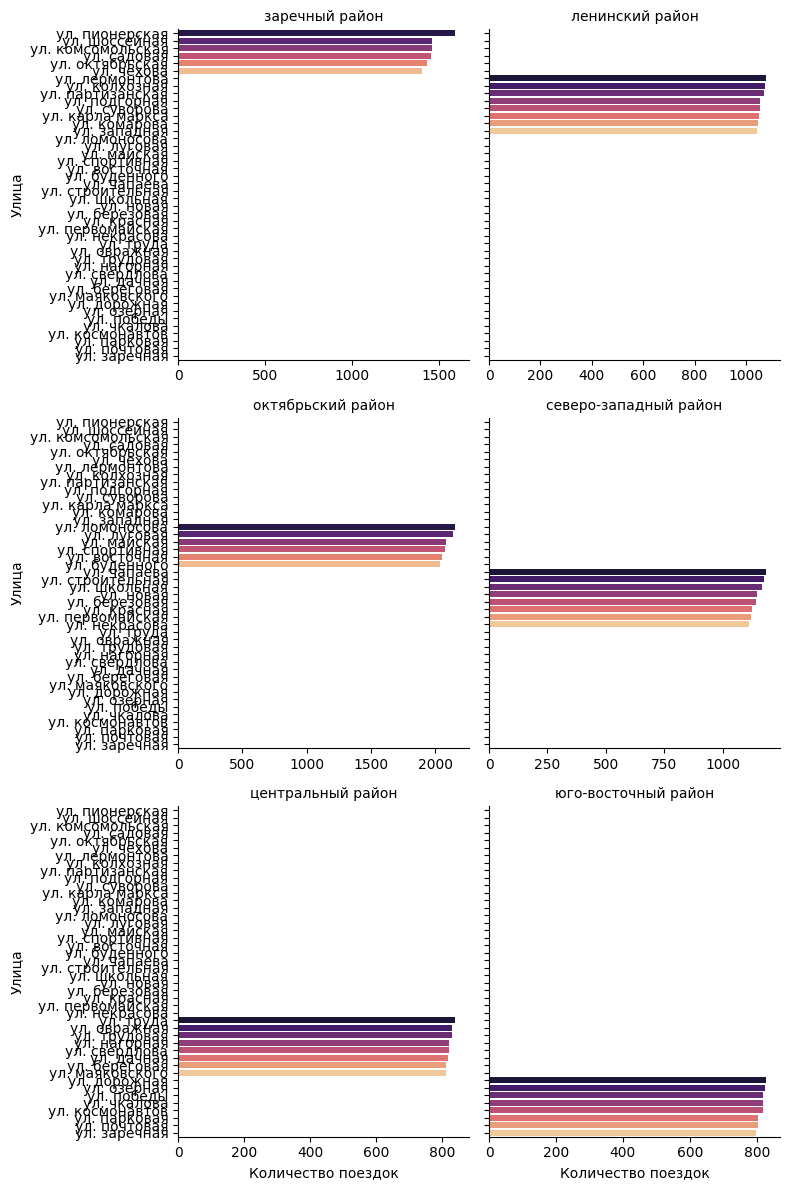

In [13]:
# Группируем по району и стартовой улице
street_distribution = df2.groupby(['Start District', 'Start Location']).size().reset_index(name='Поездок')

# Сортируем внутри каждого района по убыванию количества поездок
street_distribution = street_distribution.sort_values(['Start District', 'Поездок'], ascending=[True, False])
g = sns.FacetGrid(
    street_distribution.groupby('Start District').head(8),  # Топ-5 улиц на район
    col='Start District', col_wrap=2, height=4, sharex=False
)
g.map_dataframe(sns.barplot, x='Поездок', y='Start Location', palette='magma')
g.set_titles(col_template="{col_name} район")
g.set_axis_labels("Количество поездок", "Улица")
plt.tight_layout()
plt.show()


In [14]:
df2['Day Type'] = df2['Weekday'].apply(lambda x: 'Будний день' if x < 5 else 'Выходной')

district_day_type_distribution = (
    df2.groupby(['Day Type', 'Start District'])
       .size()
       .reset_index(name='Количество поездок')
)

day_type_order = ['Будний день', 'Выходной']
district_day_type_distribution['Day Type'] = pd.Categorical(
    district_day_type_distribution['Day Type'],
    categories=day_type_order,
    ordered=True
)

district_day_type_distribution = (
    district_day_type_distribution
    .sort_values(by=['Day Type', 'Количество поездок'], ascending=[True, False])
    .reset_index(drop=True)
)

print(district_day_type_distribution)


       Day Type   Start District  Количество поездок
0   Будний день      центральный               16893
1   Будний день    юго-восточный               11848
2   Будний день        ленинский                9881
3   Будний день  северо-западный                9845
4   Будний день      октябрьский                8408
5   Будний день         заречный                5878
6      Выходной      центральный                8847
7      Выходной    юго-восточный                7098
8      Выходной        ленинский                6055
9      Выходной  северо-западный                6049
10     Выходной      октябрьский                5316
11     Выходной         заречный                3705


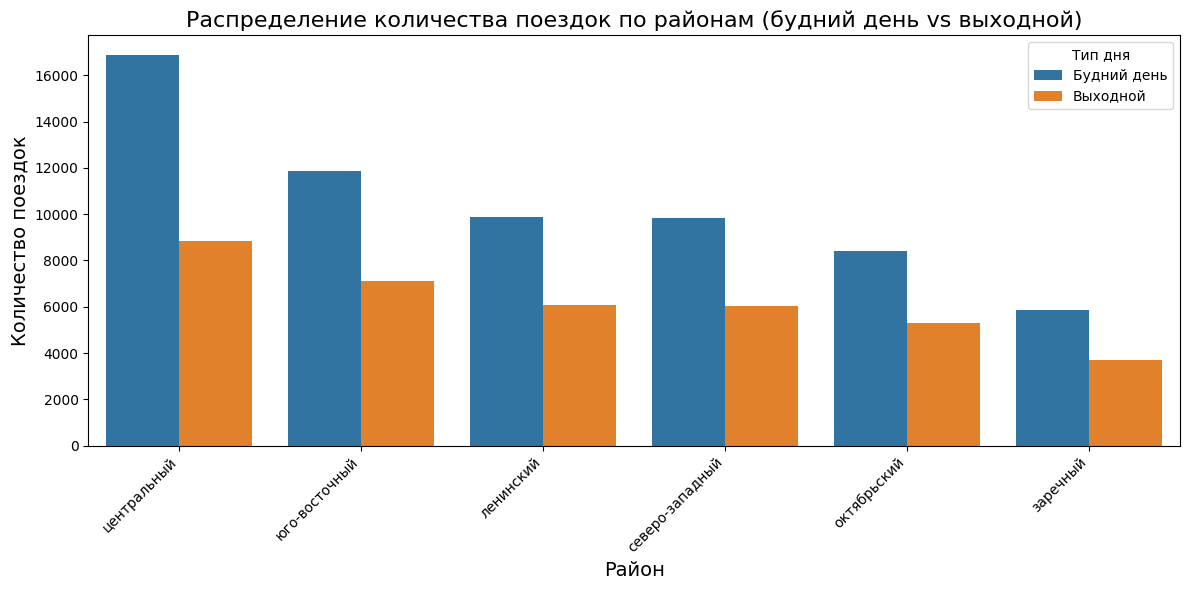

In [15]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Start District', y='Количество поездок', hue='Day Type', data=district_day_type_distribution)

plt.title('Распределение количества поездок по районам (будний день vs выходной)', fontsize=16)
plt.xlabel('Район', fontsize=14)
plt.ylabel('Количество поездок', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Тип дня')

plt.tight_layout()
plt.show()

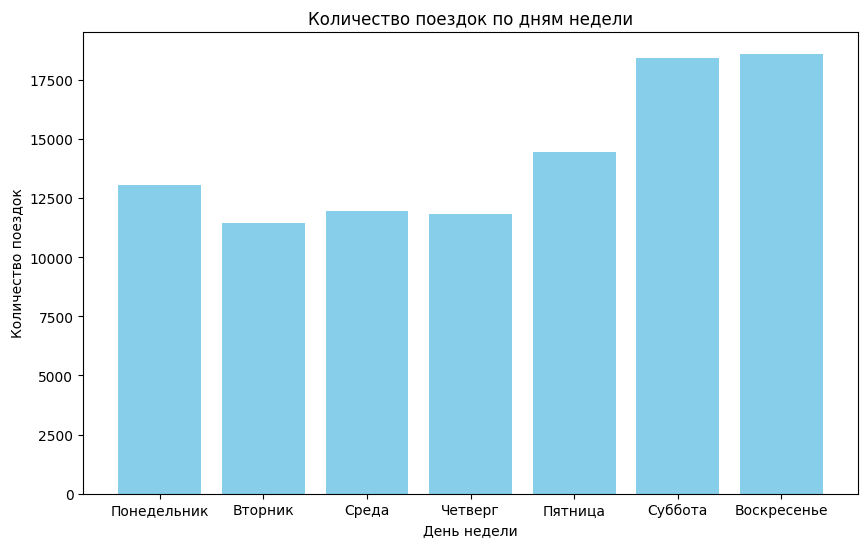

День недели с наибольшим количеством поездок: Воскресенье


In [16]:
weekday_counts = df2['Weekday'].value_counts().sort_index()

# Создаем график
plt.figure(figsize=(10, 6))
plt.bar(weekday_counts.index, weekday_counts.values, color='skyblue')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.title('Количество поездок по дням недели')
plt.xticks(ticks=range(7), labels=['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье'])
plt.show()

# Выводим день недели с наибольшим количеством поездок
max_day = weekday_counts.idxmax()
print(f"День недели с наибольшим количеством поездок: {['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье'][max_day]}")

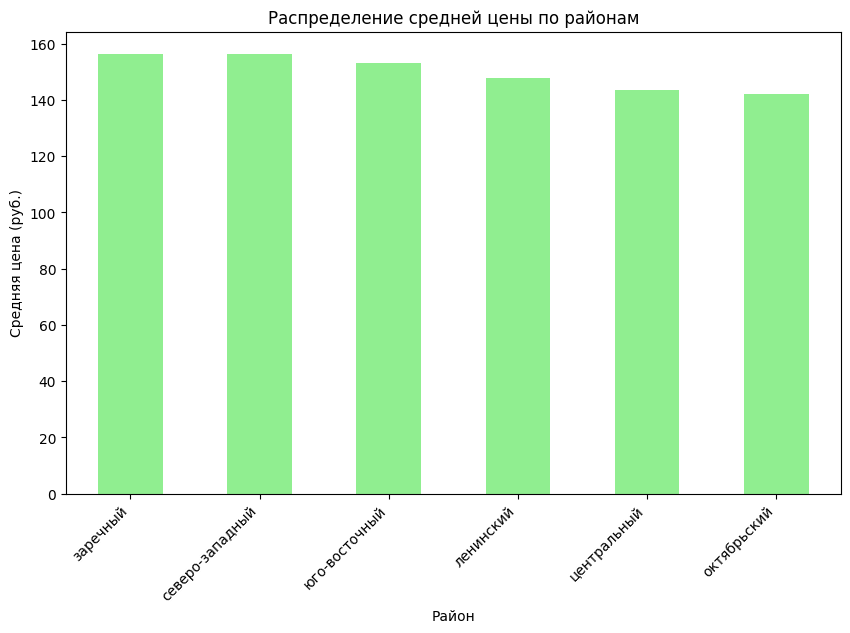

In [17]:
district_price = df2.groupby('Start District')['Trip Cost'].mean().sort_values(ascending=False)

# Строим график
plt.figure(figsize=(10, 6))
district_price.plot(kind='bar', color='lightgreen')
plt.xlabel('Район')
plt.ylabel('Средняя цена (руб.)')
plt.title('Распределение средней цены по районам')
plt.xticks(rotation=45, ha='right')
plt.show()

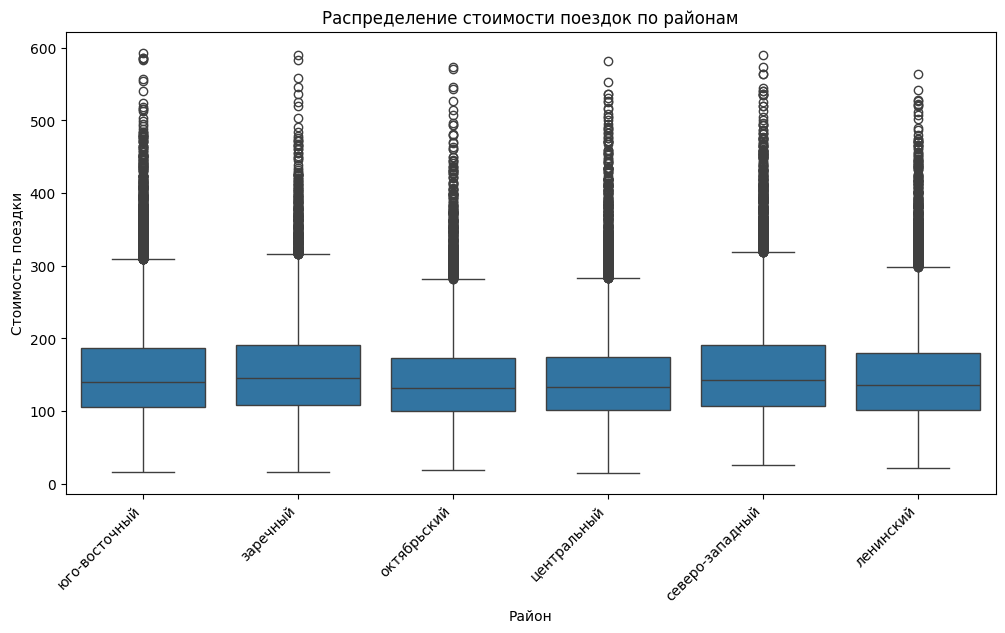

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Start District', y='Trip Cost', data=df2)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Район')
plt.ylabel('Стоимость поездки')
plt.title('Распределение стоимости поездок по районам')

plt.show()

C:\Temp\ipykernel_12700\397255798.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Time of Day', data=df2, palette='Set2')


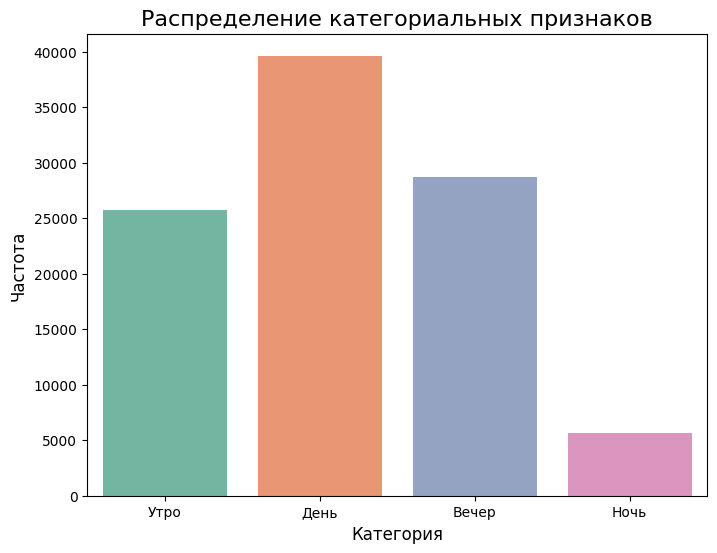

In [19]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Time of Day', data=df2, palette='Set2')

plt.title('Распределение категориальных признаков', fontsize=16)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Частота', fontsize=12)

plt.show()

In [16]:
print(df2['Trip Cost'].mean())
print(df2['Trip Cost'].max())
print(df2['Trip Cost'].median())
df2[df2['Start Season'] == 'Весна']['Trip Cost'].sum()

149.13770173206575
593.3666666666667
137.41666666666669


5344772.9

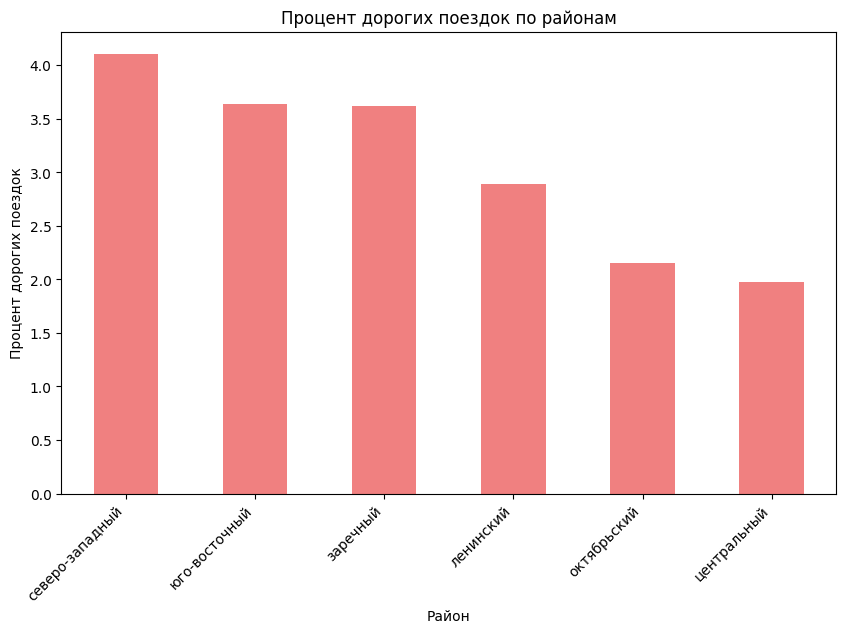

In [21]:
threshold = 300

# Рассчитываем, сколько поездок в каждом районе превышают этот порог
df2['Expensive Trip'] = df2['Trip Cost'] > threshold

district_expensive_percentage = df2.groupby('Start District')['Expensive Trip'].mean() * 100
district_expensive_percentage = district_expensive_percentage.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
district_expensive_percentage.plot(kind='bar', color='lightcoral')
plt.xlabel('Район')
plt.ylabel('Процент дорогих поездок')
plt.title('Процент дорогих поездок по районам')
plt.xticks(rotation=45, ha='right')
plt.show()

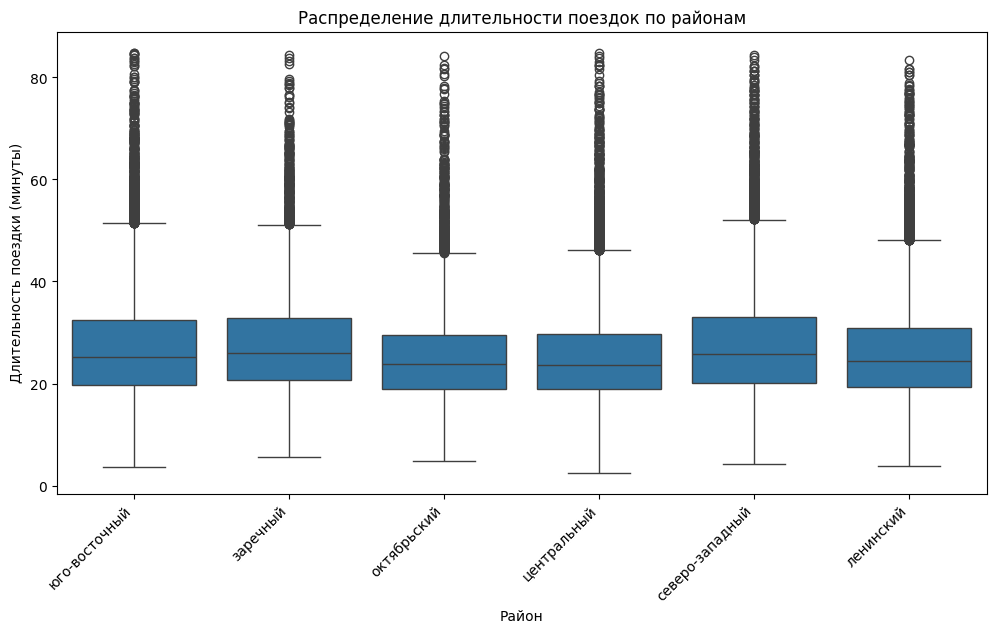

Start District
заречный           27.802877
северо-западный    27.682743
юго-восточный      27.166690
ленинский          26.159380
октябрьский        25.203389
центральный        25.185319
Name: Trip Duration, dtype: float64


In [22]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Start District', y='Trip Duration', data=df2)

# Настроим график
plt.xticks(rotation=45, ha='right')
plt.xlabel('Район')
plt.ylabel('Длительность поездки (минуты)')
plt.title('Распределение длительности поездок по районам')

# Показываем график
plt.show()
average_duration_by_district = df2.groupby('Start District')['Trip Duration'].mean().sort_values(ascending=False)
print(average_duration_by_district)

C:\Temp\ipykernel_12700\1772200853.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_durations.values, y=district_durations.index, palette="coolwarm")


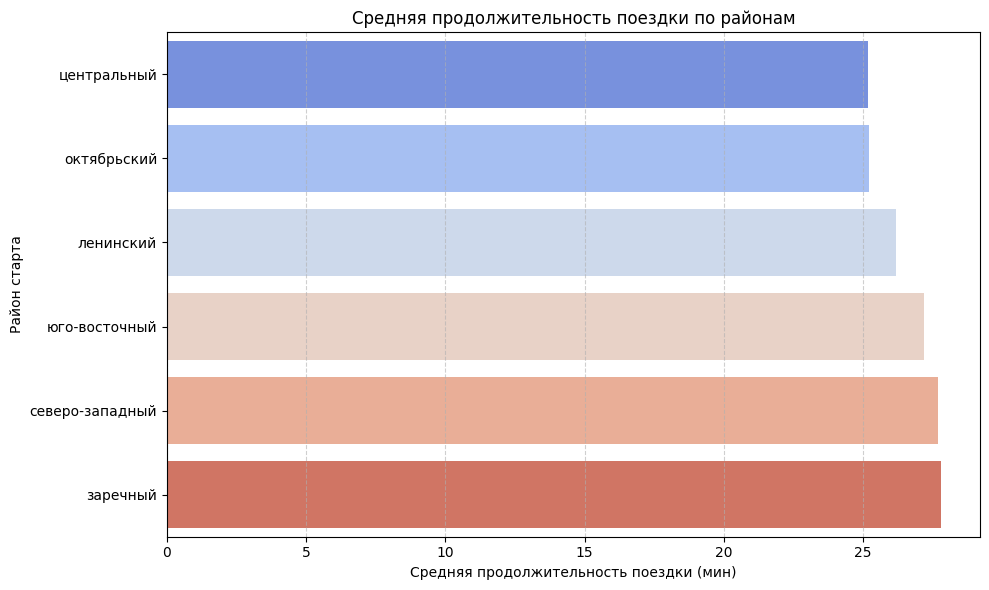

In [23]:
district_durations = df2.groupby("Start District")["Trip Duration"].mean().sort_values()

# Строим график
plt.figure(figsize=(10, 6))
sns.barplot(x=district_durations.values, y=district_durations.index, palette="coolwarm")
plt.xlabel("Средняя продолжительность поездки (мин)")
plt.ylabel("Район старта")
plt.title("Средняя продолжительность поездки по районам")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

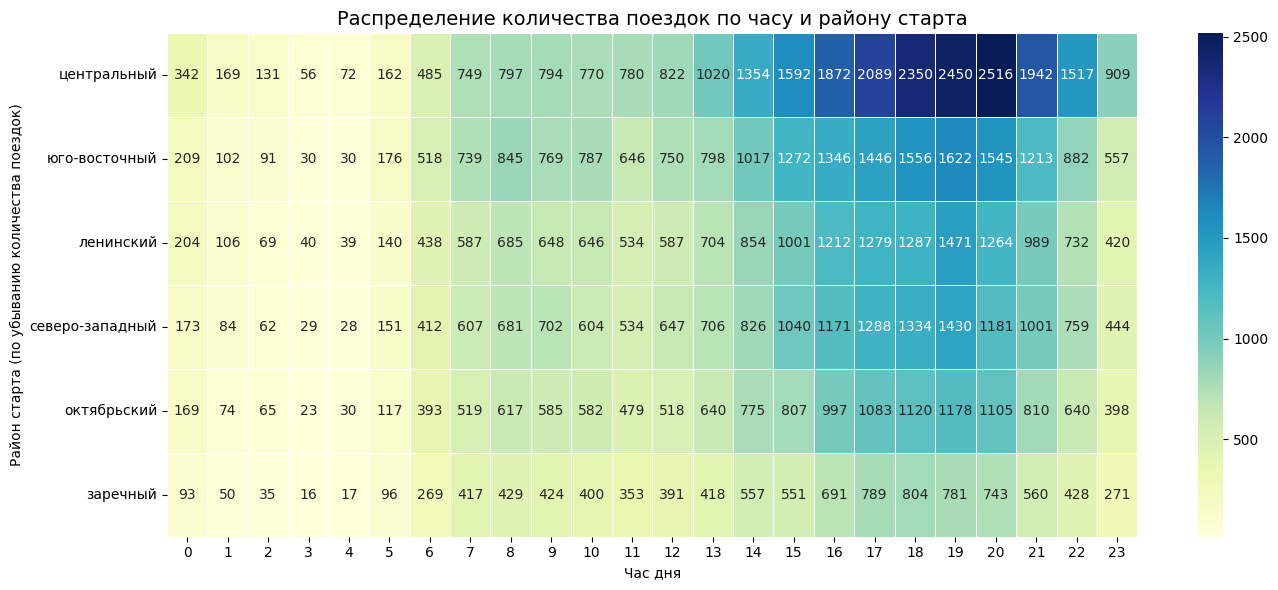

In [24]:
grouped = df2.groupby(['Start District', 'Start Hour']).size().reset_index(name='Trip Count')
district_order = df2['Start District'].value_counts().index.tolist()
pivot_table = grouped.pivot(index='Start District', columns='Start Hour', values='Trip Count').fillna(0)

pivot_table = pivot_table.reindex(district_order)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=.5)
plt.title("Распределение количества поездок по часу и району старта", fontsize=14)
plt.xlabel("Час дня")
plt.ylabel("Район старта (по убыванию количества поездок)")
plt.tight_layout()
plt.show()

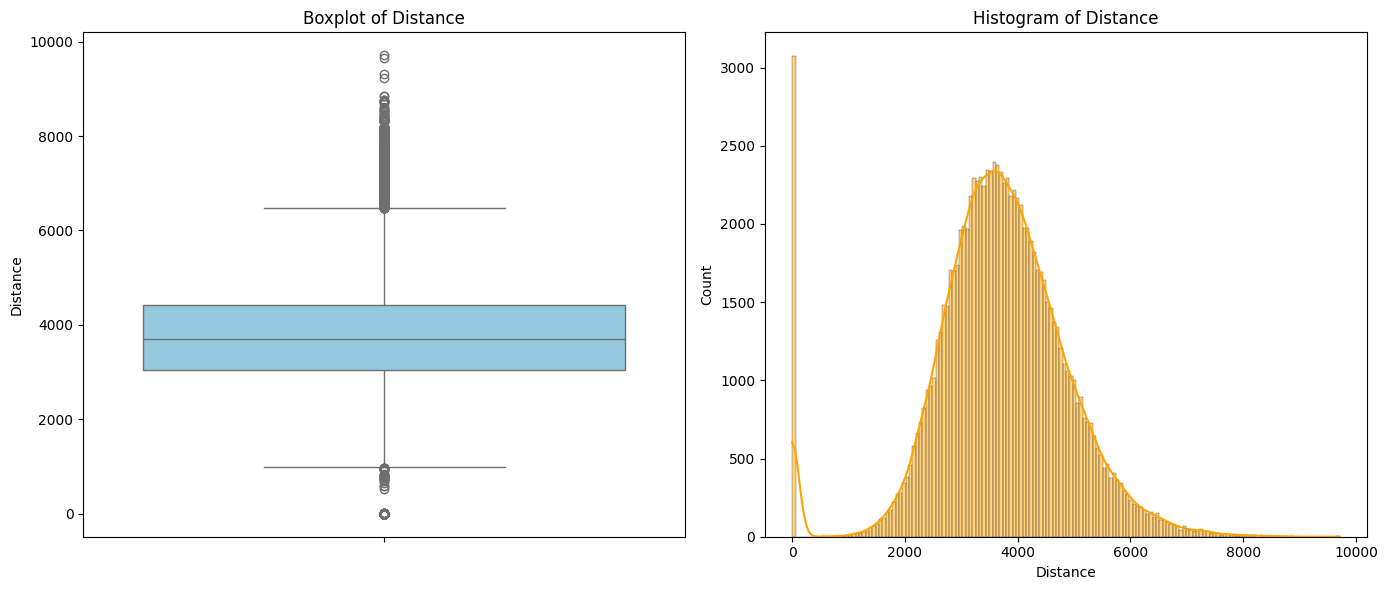

In [25]:
# Создаем графики в одном месте
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot (вертикальный)
sns.boxplot(y=df2['Distance'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Distance')

# Histplot
sns.histplot(df2['Distance'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Histogram of Distance')

plt.tight_layout()
plt.show()

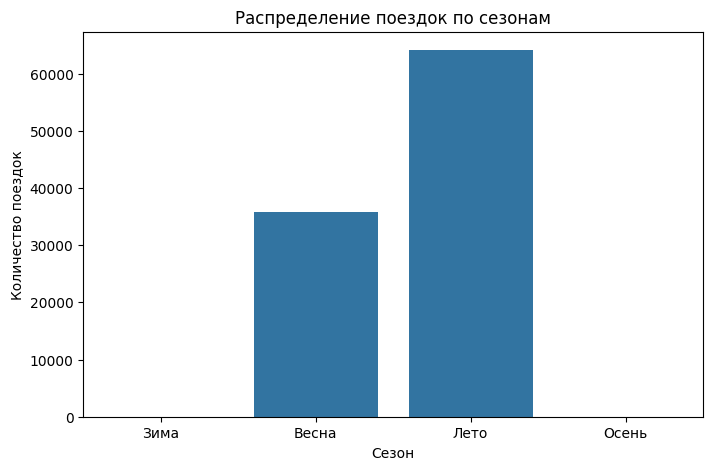

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Start Season', data=df2, order=['Зима', 'Весна', 'Лето', 'Осень'])
plt.title('Распределение поездок по сезонам')
plt.xlabel('Сезон')
plt.ylabel('Количество поездок')
plt.show()

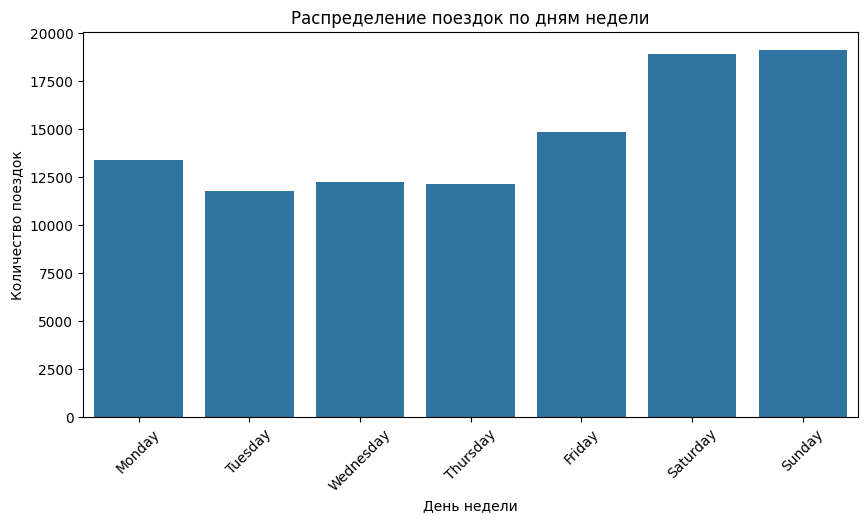

In [27]:
df["Start Date"] = pd.to_datetime(df["Start Date"])

# Добавляем колонку с днем недели
df["Day of Week"] = df["Start Date"].dt.day_name()

# Строим график
plt.figure(figsize=(10, 5))
sns.countplot(x=df["Day of Week"], order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
plt.xticks(rotation=45)
plt.xlabel("День недели")
plt.ylabel("Количество поездок")
plt.title("Распределение поездок по дням недели")
plt.show()

# Анализ датасета с погодой

In [29]:
df_w = pd.read_csv(PATH_OUT + '\\weather.csv', sep=',', encoding='utf-8', skipinitialspace=True, decimal=',')

df_w.drop(0, inplace=True)
df_w['Datetime'] = pd.to_datetime(df_w['Datetime']) 
df_w['Day'] = df_w['Datetime'].dt.day  
df_w['Month'] =df_w['Datetime'].dt.month  
df_w['Time'] = df_w['Datetime'].dt.time

seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}
df_w['Season'] = df_w['Month'].map(seasons)

df_w.isna().sum()

Datetime                0
Temperature            55
Precipitation Total    30
Wind Gust               0
Wind Speed             16
Cloud Cover Total      20
Sunshine Duration      12
Day                     0
Month                   0
Time                    0
Season                  0
dtype: int64

In [30]:
df_w['Precipitation Total'] = df_w['Precipitation Total'].ffill()
df_w['Wind Speed'] = df_w['Wind Speed'].ffill()
df_w['Cloud Cover Total'] = df_w['Cloud Cover Total'].ffill()
df_w['Sunshine Duration'] = df_w['Sunshine Duration'].ffill()
print(df_w.isna().sum())
df_w

Datetime                0
Temperature            55
Precipitation Total     0
Wind Gust               0
Wind Speed              0
Cloud Cover Total       0
Sunshine Duration       0
Day                     0
Month                   0
Time                    0
Season                  0
dtype: int64


,Datetime,Temperature,Precipitation Total,Wind Gust,Wind Speed,Cloud Cover Total,Sunshine Duration,Day,Month,Time,Season
1,2023-04-01 00:00:00,8.740245,0.1,48.6,21.638964,90,0,1,4,00:00:00,Весна
2,2023-04-01 01:00:00,9.040245,0.2,55.44,22.493519,74,0,1,4,01:00:00,Весна
3,2023-04-01 02:00:00,8.880245,0.3,55.8,22.26477,72,0,1,4,02:00:00,Весна
4,2023-04-01 03:00:00,8.690246,0.3,55.44,21.94524,77,0,1,4,03:00:00,Весна
5,2023-04-01 04:00:00,8.630245,0.3,48.96,22.42427,78,0,1,4,04:00:00,Весна
...,...,...,...,...,...,...,...,...,...,...,...
3668,2023-08-31 19:00:00,16.940245,0,10.799999,1.08,89,1.4999998,31,8,19:00:00,Лето
3669,2023-08-31 20:00:00,16.630245,0,11.159999,1.1384199,83,0,31,8,20:00:00,Лето
3670,2023-08-31 21:00:00,17.080246,0.1,17.64,3.396233,82,0,31,8,21:00:00,Лето
3671,2023-08-31 22:00:00,17.180244,0,21.599998,7.2359104,80,0,31,8,22:00:00,Лето


In [31]:
# Уехавшие — по Start Location
departures = (
    df2.set_index('Start Date')
      .groupby('Start Location')
      .resample('1h')
      .size()
      .reset_index(name='Departures')
)

# Приехавшие — по End Location
arrivals = (
    df2.set_index('End Date')
      .groupby('End Location')
      .resample('1h')
      .size()
      .reset_index(name='Arrivals')
) 
departures.rename(columns={'Start Date': 'Datetime', 'Start Location': 'Location'}, inplace=True)
arrivals.rename(columns={'End Date': 'Datetime', 'End Location': 'Location'}, inplace=True)

# Объединяем по локации и времени
traffic_by_hour = pd.merge(departures, arrivals, on=['Datetime', 'Location'], how='outer')

# Заполняем пропущенные значения нулями
traffic_by_hour.fillna(0, inplace=True)

# Сортируем для читаемости
traffic_by_hour = traffic_by_hour.sort_values(by=['Location', 'Datetime']).reset_index(drop=True) 
print(traffic_by_hour)

             Location            Datetime  Departures  Arrivals
0       ул. береговая 2023-04-22 10:00:00         0.0       1.0
1       ул. береговая 2023-04-22 11:00:00         0.0       0.0
2       ул. береговая 2023-04-22 12:00:00         0.0       0.0
3       ул. береговая 2023-04-22 13:00:00         1.0       0.0
4       ул. береговая 2023-04-22 14:00:00         2.0       0.0
...               ...                 ...         ...       ...
221948      ул. южная 2023-07-31 18:00:00         0.0       1.0
221949      ул. южная 2023-07-31 19:00:00         0.0       0.0
221950      ул. южная 2023-07-31 20:00:00         0.0       0.0
221951      ул. южная 2023-07-31 21:00:00         2.0       2.0
221952      ул. южная 2023-07-31 22:00:00         1.0       0.0

[221953 rows x 4 columns]


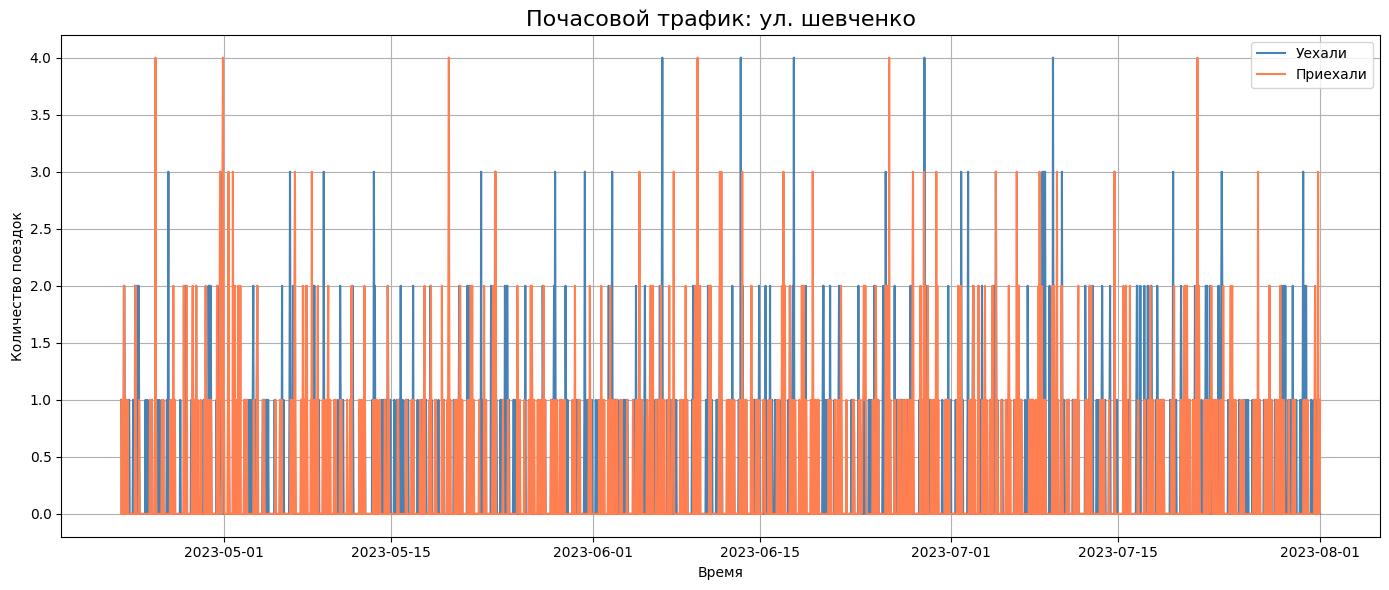

In [32]:
# Фильтруем по нужной локации
location_name = 'ул. шевченко'
location_traffic = traffic_by_hour[traffic_by_hour['Location'] == location_name]

# Строим график
plt.figure(figsize=(14, 6))
plt.plot(location_traffic['Datetime'], location_traffic['Departures'], label='Уехали', color='steelblue')
plt.plot(location_traffic['Datetime'], location_traffic['Arrivals'], label='Приехали', color='coral')

plt.title(f'Почасовой трафик: {location_name}', fontsize=16)
plt.xlabel('Время')
plt.ylabel('Количество поездок')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

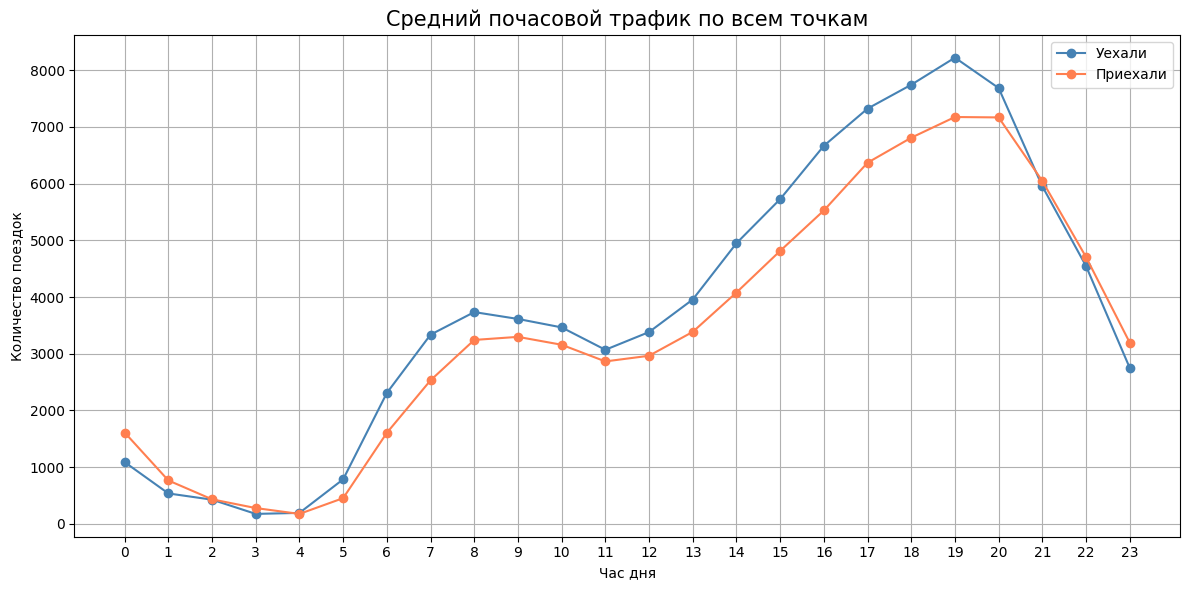

In [33]:
traffic_by_hour['Hour'] = traffic_by_hour['Datetime'].dt.hour
hourly_traffic = (
    traffic_by_hour.groupby('Hour')[['Departures', 'Arrivals']]
    .sum()
    .reset_index()
)
plt.figure(figsize=(12, 6))
plt.plot(hourly_traffic['Hour'], hourly_traffic['Departures'], label='Уехали', marker='o', color='steelblue')
plt.plot(hourly_traffic['Hour'], hourly_traffic['Arrivals'], label='Приехали', marker='o', color='coral')

plt.title('Средний почасовой трафик по всем точкам', fontsize=15)
plt.xlabel('Час дня')
plt.ylabel('Количество поездок')
plt.xticks(range(0, 24))  # каждые часы от 0 до 23
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [34]:
df2['Start Location'].unique()

array(['ул. шевченко', 'ул. чехова', 'ул. буденного', 'ул. труда',
       'ул. первомайская', 'ул. лесная', 'ул. пролетарская',
       'ул. комарова', 'ул. западная', 'ул. свободы', 'ул. коммунальная',
       'ул. зеленая', 'ул. шоссейная', 'ул. центральная', 'ул. новая',
       'ул. энтузиастов', nan, 'ул. восточная', 'ул. лермонтова',
       'ул. школьная', 'ул. пушкина', 'ул. подгорная', 'ул. рябиновая',
       'ул. солнечная', 'ул. мичурина', 'ул. партизанская',
       'ул. вокзальная', 'ул. комсомольская', 'ул. майская',
       'ул. красноармейская', 'ул. рабочая', 'ул. почтовая', 'ул. дачная',
       'ул. заводская', 'ул. ломоносова', 'ул. карла маркса',
       'ул. советская', 'ул. красная', 'ул. дзержинского',
       'ул. пионерская', 'ул. ленина', 'ул. сиреневая', 'ул. гагарина',
       'ул. юбилейная', 'ул. цветочная', 'ул. набережная', 'ул. сосновая',
       'ул. спортивная', 'ул. полевая', 'ул. строительная', 'ул. озерная',
       'ул. энергетиков', 'ул. южная', 'ул. некрас

In [35]:
# Группируем по направлению: откуда -> куда
top_routes = (
    df2.groupby(['Start Location', 'End Location'])
    .size()
    .reset_index(name='Количество поездок')
    .sort_values(by='Количество поездок', ascending=False)
)

# Покажем топ-10 самых популярных направлений
print(top_routes.head(10))


      Start Location    End Location  Количество поездок
3280     ул. луговая  ул. спортивная                  61
3372     ул. майская  ул. спортивная                  60
186    ул. буденного   ул. буденного                  57
494    ул. восточная     ул. луговая                  54
3301     ул. майская   ул. буденного                  53
6598  ул. спортивная   ул. восточная                  51
6629  ул. спортивная     ул. майская                  50
220    ул. буденного     ул. майская                  47
257    ул. буденного  ул. спортивная                  47
493    ул. восточная  ул. ломоносова                  46


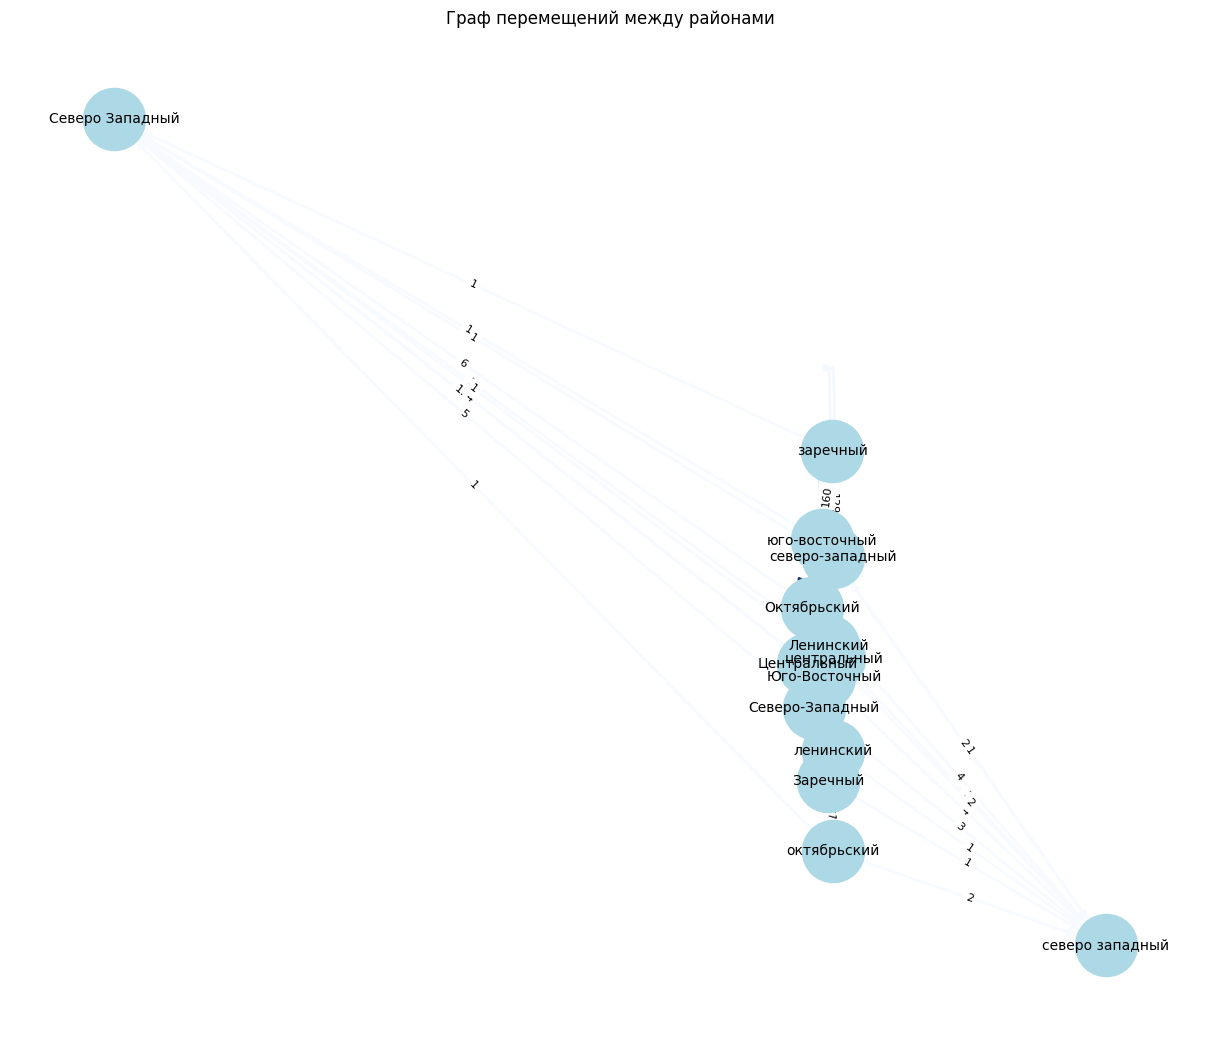

In [36]:
import networkx as nx
district_flow = df.groupby(['Start District', 'End District']).size().reset_index(name='Trips')
# Построим граф направлений
G = nx.DiGraph()

# Добавим ребра с весами
for _, row in district_flow.iterrows():
    G.add_edge(row['Start District'], row['End District'], weight=row['Trips'])

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42)

# Толщина ребра пропорциональна количеству поездок
edges = G.edges(data=True)
weights = [d['weight'] for (_, _, d) in edges]
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, edge_color=weights, edge_cmap=plt.cm.Blues, width=2.0)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d['weight'] for u, v, d in edges}, font_size=8)
plt.title("Граф перемещений между районами")
plt.show()

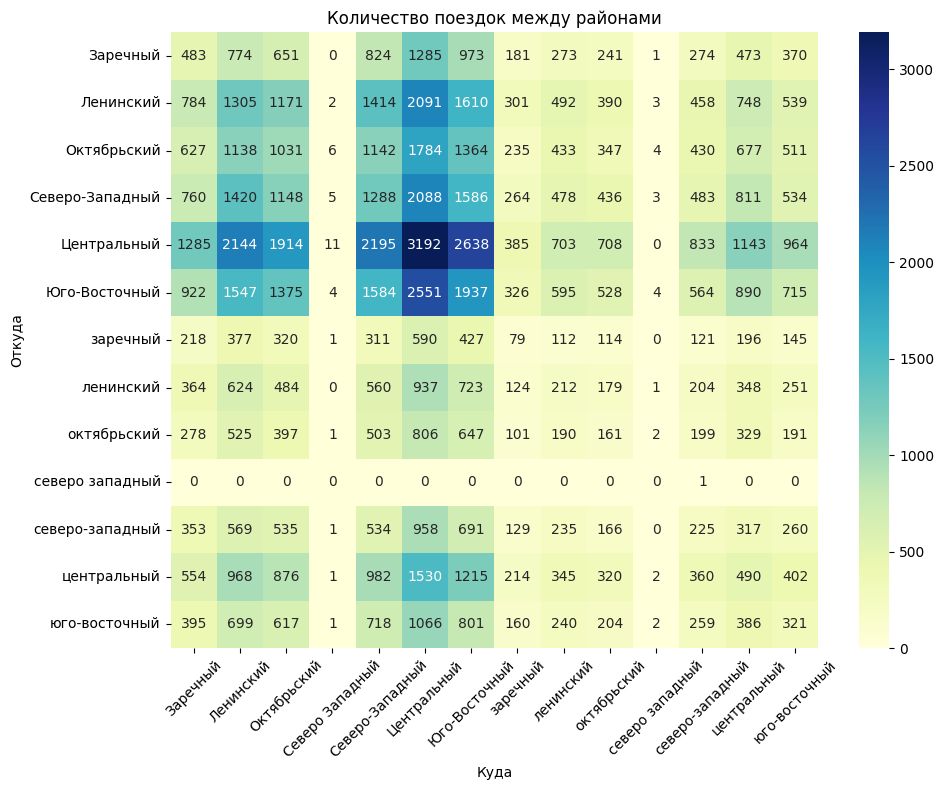

In [37]:
# Пивот-таблица для тепловой карты
pivot_table = district_flow.pivot(index='Start District', columns='End District', values='Trips').fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Количество поездок между районами")
plt.ylabel("Откуда")
plt.xlabel("Куда")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [38]:
speed_by_weekday = df2.groupby('Weekday')['Speed (km/h)'].agg(['mean', 'count']).reset_index()

# Получаем имена дней недели для отображения на графике
weekday_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
speed_by_weekday['Weekday Name'] = speed_by_weekday['Weekday'].map(lambda x: weekday_names[x])

# Сортируем по дню недели для корректного отображения
speed_by_weekday = speed_by_weekday.sort_values(by='Weekday')

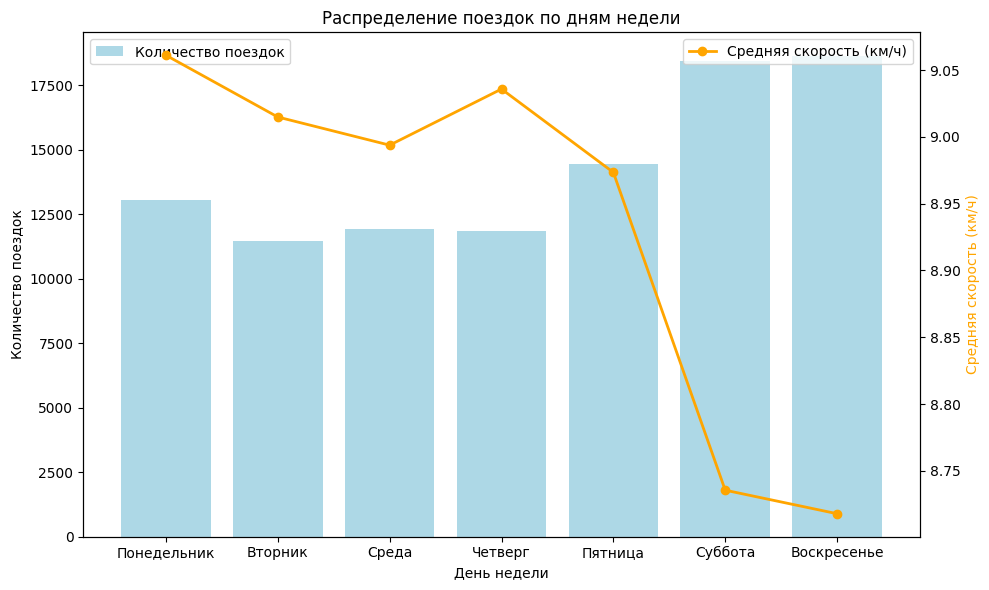

In [39]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# График количества поездок
ax1.bar(speed_by_weekday['Weekday Name'], speed_by_weekday['count'], color='lightblue', label='Количество поездок')
ax1.set_xlabel('День недели')
ax1.set_ylabel('Количество поездок')
ax1.set_title('Распределение поездок по дням недели')

# Добавим второй график для средней скорости
ax2 = ax1.twinx()
ax2.plot(speed_by_weekday['Weekday Name'], speed_by_weekday['mean'], color='orange', marker='o', label='Средняя скорость (км/ч)', linewidth=2)
ax2.set_ylabel('Средняя скорость (км/ч)', color='orange')

# Показать легенду
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Показать график
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Temp\ipykernel_12700\2470487936.py:43: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


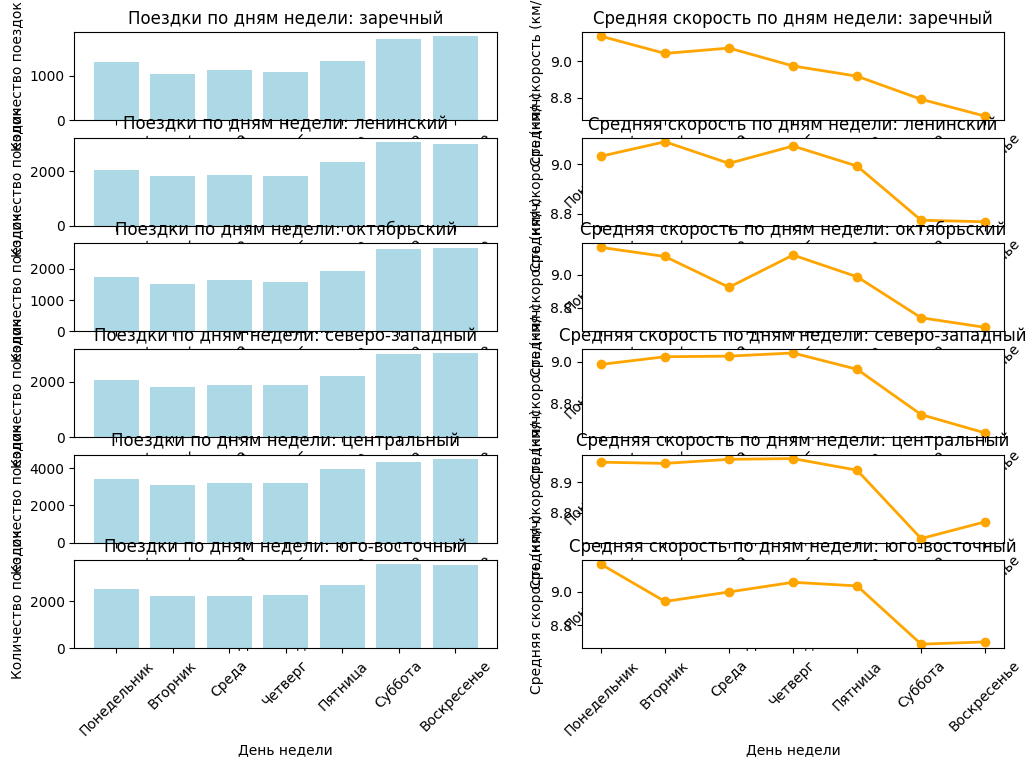

In [69]:
# Преобразуем столбец Start Date в datetime
df2['Start Date'] = pd.to_datetime(df['Start Date'])

# Извлекаем день недели (0 - Понедельник, 6 - Воскресенье)
df2['Weekday'] = df2['Start Date'].dt.weekday

# Группируем по району, дню недели и считаем количество поездок и среднюю скорость
speed_by_weekday_district = df2.groupby(['Start District', 'Weekday'])['Speed (km/h)'].agg(['mean', 'count']).reset_index()

# Получаем имена дней недели для отображения на графике
weekday_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
speed_by_weekday_district['Weekday Name'] = speed_by_weekday_district['Weekday'].map(lambda x: weekday_names[x])

# Сортируем по району и дню недели
speed_by_weekday_district = speed_by_weekday_district.sort_values(by=['Start District', 'Weekday'])
# Размер графика
plt.figure(figsize=(12, 8))

# Список уникальных районов
districts = speed_by_weekday_district['Start District'].unique()

# Создадим графики для каждого района
for i, district in enumerate(districts):
    plt.subplot(len(districts), 2, 2 * i + 1)  # Строим подграфик для распределения поездок
    district_data = speed_by_weekday_district[speed_by_weekday_district['Start District'] == district]
    
    # Количество поездок
    plt.bar(district_data['Weekday Name'], district_data['count'], color='lightblue')
    plt.title(f'Поездки по дням недели: {district}')
    plt.xlabel('День недели')
    plt.ylabel('Количество поездок')
    plt.xticks(rotation=45)

    plt.subplot(len(districts), 2, 2 * i + 2)  # Строим подграфик для средней скорости
    # Средняя скорость
    plt.plot(district_data['Weekday Name'], district_data['mean'], color='orange', marker='o', label='Средняя скорость (км/ч)', linewidth=2)
    plt.title(f'Средняя скорость по дням недели: {district}')
    plt.xlabel('День недели')
    plt.ylabel('Средняя скорость (км/ч)')
    plt.xticks(rotation=45)

# Показать график
plt.tight_layout()
plt.show()


C:\Temp\ipykernel_12700\3080839194.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  street_df.loc[:, 'Hour'] = street_df['Start Date'].dt.hour
C:\Temp\ipykernel_12700\3080839194.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  street_df.loc[:, 'Hour'] = street_df['Start Date'].dt.hour
C:\Temp\ipykernel_12700\3080839194.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

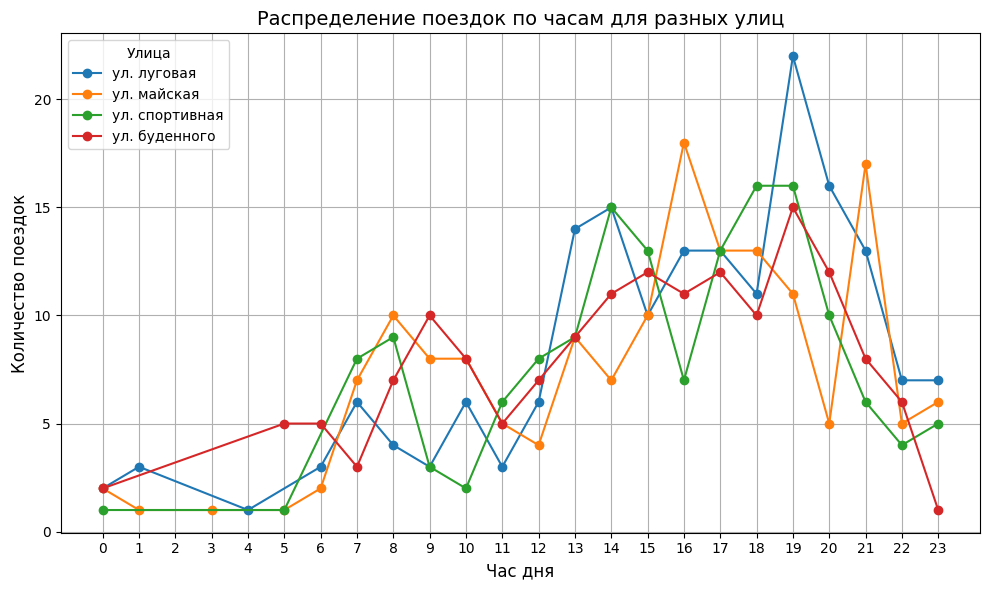

In [41]:
# Список улиц для анализа
streets = ['ул. луговая', 'ул. майская', 'ул. спортивная', 'ул. буденного']

# Размер графика
plt.figure(figsize=(10, 6))

# Цикл для обработки каждой улицы
for street in streets:
    # Фильтруем данные по текущей улице
    street_df = df[df['Start Location'] == street]
    
    # Извлекаем час из столбца 'Start Date' с использованием .loc
    street_df.loc[:, 'Hour'] = street_df['Start Date'].dt.hour
    
    # Группируем по часам и считаем количество поездок
    hourly_trips = street_df.groupby('Hour').size()

    # Строим график для текущей улицы
    plt.plot(hourly_trips.index, hourly_trips.values, marker='o', label=street)

# Добавляем заголовки и подписи
plt.title('Распределение поездок по часам для разных улиц', fontsize=14)
plt.xlabel('Час дня', fontsize=12)
plt.ylabel('Количество поездок', fontsize=12)
plt.xticks(range(24))  # для отображения всех 24 часов
plt.grid(True)

# Добавляем легенду
plt.legend(title='Улица')

# Показать график
plt.tight_layout()
plt.show()


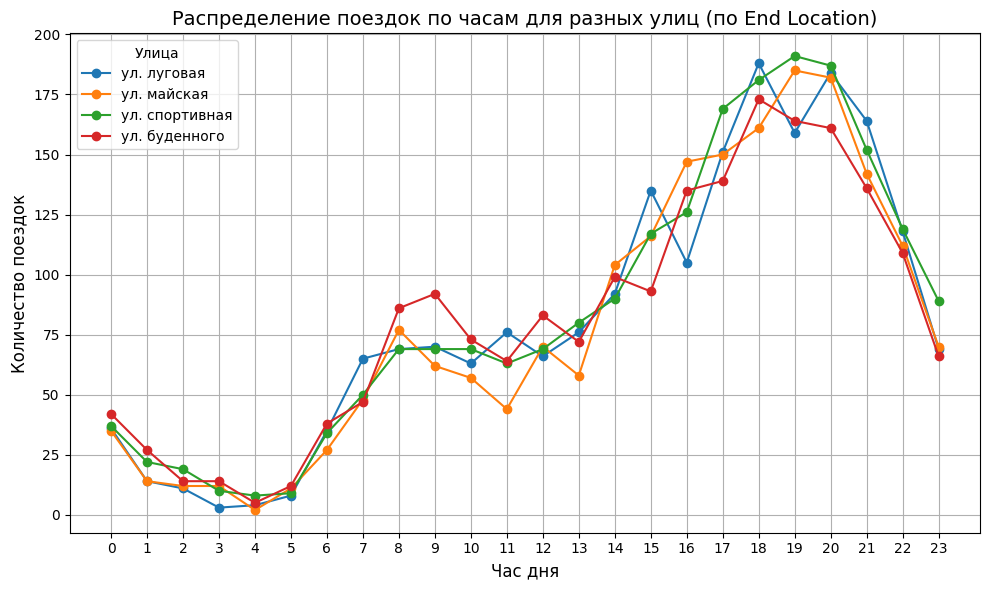

In [51]:
# Убедимся, что оба столбца в нужном формате datetime
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])

# Список улиц для анализа
streets = ['ул. луговая', 'ул. майская', 'ул. спортивная', 'ул. буденного']

# Размер графика
plt.figure(figsize=(10, 6))

# Цикл для обработки каждой улицы
for street in streets:
    # Фильтруем данные по текущей улице (например, конец поездки на этой улице)
    street_df = df[df['End Location'] == street]
    
    # Безопасно извлекаем час из End Date
    street_df = street_df.copy()  # избегаем SettingWithCopyWarning
    street_df['Hour'] = street_df['End Date'].dt.hour

    # Группируем по часам и считаем количество поездок
    hourly_trips = street_df.groupby('Hour').size()

    # Строим график для текущей улицы
    plt.plot(hourly_trips.index, hourly_trips.values, marker='o', label=street)

# Добавляем заголовки и подписи
plt.title('Распределение поездок по часам для разных улиц (по End Location)', fontsize=14)
plt.xlabel('Час дня', fontsize=12)
plt.ylabel('Количество поездок', fontsize=12)
plt.xticks(range(24))  # для отображения всех 24 часов
plt.grid(True)

# Добавляем легенду
plt.legend(title='Улица')

# Показать график
plt.tight_layout()
plt.show()

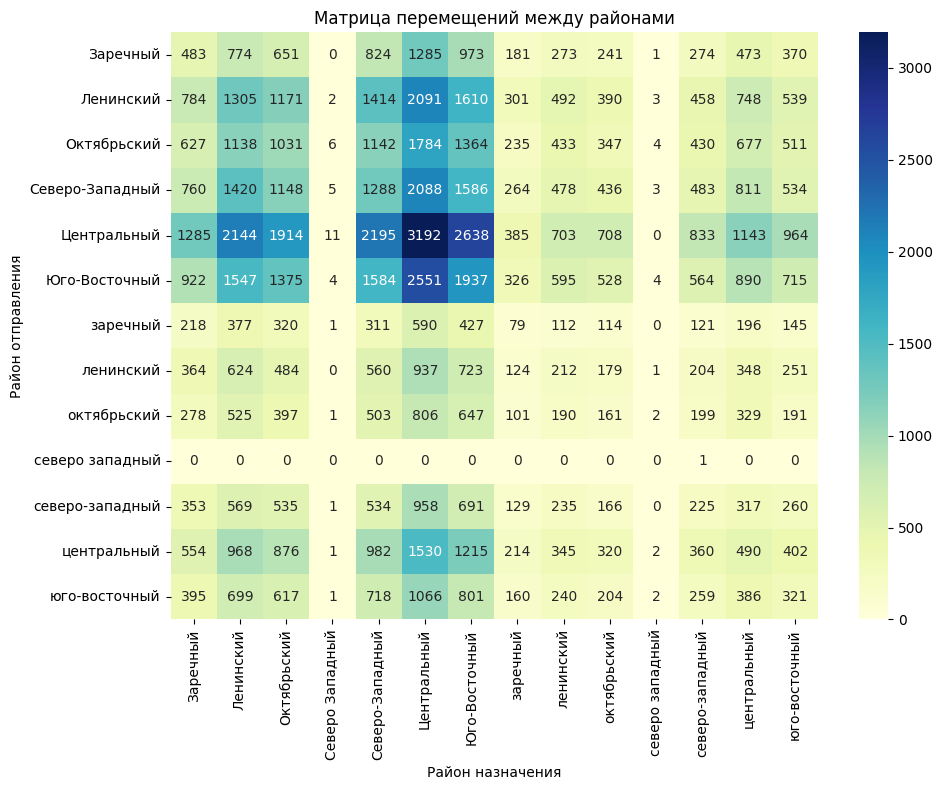